
--- DATA ---
   student_id  gender  study_hours  attendance  marks pass_fail
0           1    Male            2          75   55.0      Pass
1           2  Female            5          90   80.0      Pass
2           3    Male            1          60   40.0      Fail
3           4  Female            3          70   65.0      Pass
4           5    Male            4          85   78.0      Pass

Decision Tree Accuracy: 0.6666666666666666
Random Forest Accuracy: 0.6666666666666666


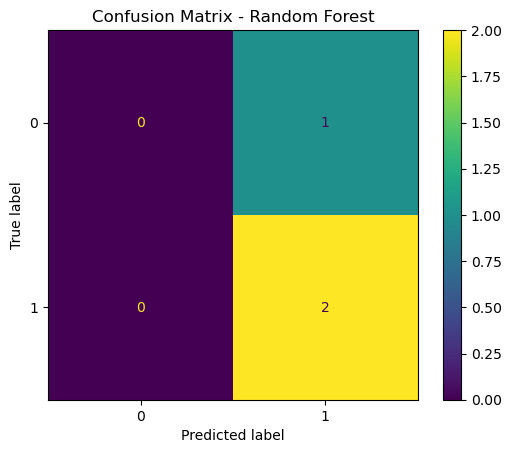

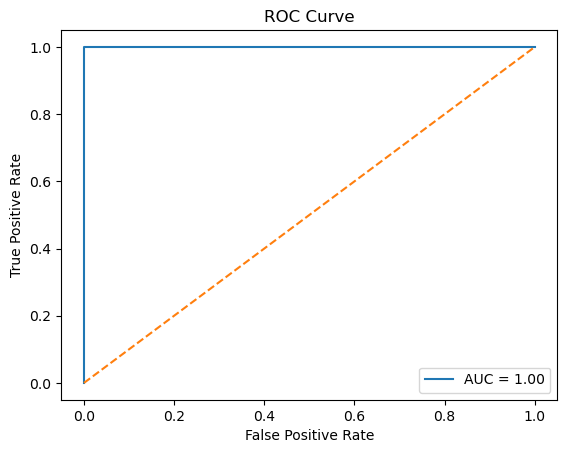

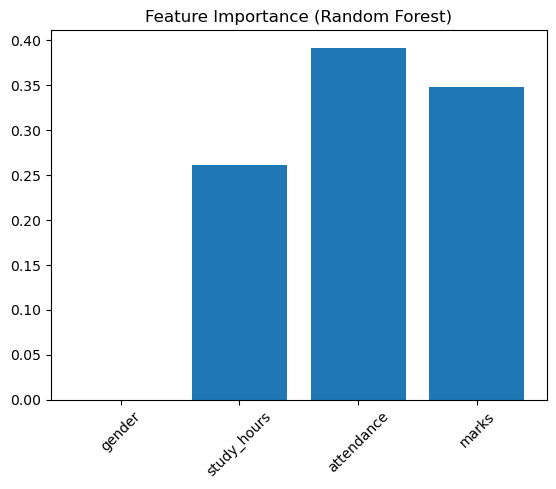


ML Project Completed!


In [1]:
# PREDICTIVE MODELING PROJECT (ML)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

df = pd.read_csv("dataset2.csv")  

print("\n--- DATA ---")
print(df.head())
 

df['marks'] = df['marks'].fillna(df['marks'].median())

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['pass_fail'] = df['pass_fail'].map({'Fail': 0, 'Pass': 1})

X = df[['gender', 'study_hours', 'attendance', 'marks']]
y = df['pass_fail']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

importance = rf_model.feature_importances_

plt.figure()
plt.bar(X.columns, importance)
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.show()

print("\nML Project Completed!")